
# Automated NET Recorgnistion and Quantification with detectron 2


In [1]:

# Optional: mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [108]:

# Basic imports
import os
import json
import random
from collections import Counter, defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

In [107]:



import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())




Torch version: 2.10.0+cu128
CUDA available: True


In [ ]:
# Install Detectron2 in Colab
# If Detectron2 is already installed in your environment, you can skip this cell
!pip -q install 'git+https://github.com/facebookresearch/detectron2.git'

In [4]:

# Detectron2 imports
from detectron2.utils.logger import setup_logger
setup_logger()

from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.evaluation import COCOEvaluator
from detectron2.data import build_detection_test_loader
from detectron2.engine import hooks


In [5]:

# Path to the train and validation data

Proj_dir = "/content/gdrive/MyDrive/Capstone_project"
TRAIN_JSON = Proj_dir + "/train_dataset/_annotations_clean.coco.json"
VAL_JSON   = Proj_dir + "/validate/_annotations_clean.coco.json"

TRAIN_IMG_DIR = Proj_dir + "/train_dataset"
VAL_IMG_DIR   = Proj_dir + "/validate"


##  Register the datasets

In [6]:

# Clean up old registrations if they already exist
for name in ["nets_train", "nets_val"]:
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
    if name in MetadataCatalog.list():
        MetadataCatalog.remove(name)

register_coco_instances("nets_train", {}, TRAIN_JSON, TRAIN_IMG_DIR)
register_coco_instances("nets_val", {}, VAL_JSON, VAL_IMG_DIR)

train_dicts = DatasetCatalog.get("nets_train")
val_dicts = DatasetCatalog.get("nets_val")

train_meta = MetadataCatalog.get("nets_train")
val_meta = MetadataCatalog.get("nets_val")

print("Train size:", len(train_dicts))
print("Val size:", len(val_dicts))
print("thing_classes:", train_meta.thing_classes)


[04/02 10:37:45 d2.data.datasets.coco]: Loading /content/gdrive/MyDrive/Capstone_project/train_dataset/_annotations_clean.coco.json takes 2.78 seconds.
[04/02 10:37:45 d2.data.datasets.coco]: Loaded 228 images in COCO format from /content/gdrive/MyDrive/Capstone_project/train_dataset/_annotations_clean.coco.json
[04/02 10:37:46 d2.data.datasets.coco]: Loading /content/gdrive/MyDrive/Capstone_project/validate/_annotations_clean.coco.json takes 1.41 seconds.
[04/02 10:37:46 d2.data.datasets.coco]: Loaded 22 images in COCO format from /content/gdrive/MyDrive/Capstone_project/validate/_annotations_clean.coco.json
Train size: 228
Val size: 22
thing_classes: ['NETs', 'non-net']


##  Inspect class distribution before training

In [7]:

def summarize_dataset(dataset_dicts, metadata, name="dataset"):
    counter = Counter()
    images_per_class = defaultdict(int)

    for record in dataset_dicts:
        seen_in_image = set()
        for ann in record["annotations"]:
            cid = ann["category_id"]
            counter[cid] += 1
            seen_in_image.add(cid)
        for cid in seen_in_image:
            images_per_class[cid] += 1

    print(f"Summary for {name}")
    print("-" * 40)
    for cid, class_name in enumerate(metadata.thing_classes):
        print(
            f"class_id={cid:>2} | class_name={class_name:<20} | "
            f"instances={counter[cid]:>5} | images={images_per_class[cid]:>4}"
        )

summarize_dataset(train_dicts, train_meta, "train")
summarize_dataset(val_dicts, val_meta, "val")

Summary for train
----------------------------------------
class_id= 0 | class_name=NETs                 | instances= 1728 | images= 195
class_id= 1 | class_name=non-net              | instances= 3234 | images= 207
Summary for val
----------------------------------------
class_id= 0 | class_name=NETs                 | instances=  152 | images=  19
class_id= 1 | class_name=non-net              | instances=  379 | images=  19


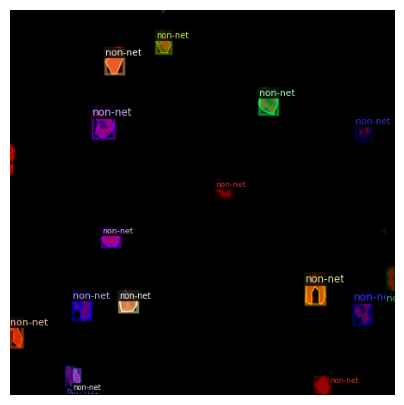

In [8]:

# Visual sanity check
sample = random.choice(train_dicts)
img = cv2.imread(sample["file_name"])
vis = Visualizer(img[:, :, ::-1], metadata=train_meta, scale=0.7)
out = vis.draw_dataset_dict(sample)
plt.figure(figsize=(5, 5))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis("off")
plt.show()



##  Configure training



In [9]:
#Configuration settings
OUTPUT_DIR = Proj_dir + "/models/Detectron2_models_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.OUTPUT_DIR = OUTPUT_DIR
cfg.DATASETS.TRAIN = ("nets_train",)
cfg.DATASETS.TEST = ("nets_val",)

cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 5000
cfg.SOLVER.STEPS = []
cfg.SOLVER.CHECKPOINT_PERIOD = 500

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2

cfg.TEST.EVAL_PERIOD = 500
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3


In [10]:

class TrainerWithVal(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        output_folder = output_folder or os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, output_dir=output_folder)

trainer = TrainerWithVal(cfg)
trainer.resume_or_load(resume=False)

[04/02 10:38:17 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:00, 218MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


## Train model

In [19]:
trainer.train()

[03/31 12:10:44 d2.engine.train_loop]: Starting training from iteration 0
[03/31 12:10:53 d2.utils.events]:  eta: 0:35:32  iter: 19  total_loss: 3.277  loss_cls: 1.165  loss_box_reg: 0.7942  loss_mask: 0.6958  loss_rpn_cls: 0.4866  loss_rpn_loc: 0.1058    time: 0.4358  last_time: 0.3683  data_time: 0.0204  last_data_time: 0.0060   lr: 4.9953e-06  max_mem: 2280M
[03/31 12:11:01 d2.utils.events]:  eta: 0:32:59  iter: 39  total_loss: 3.068  loss_cls: 1.081  loss_box_reg: 0.8092  loss_mask: 0.6924  loss_rpn_cls: 0.3568  loss_rpn_loc: 0.117    time: 0.4156  last_time: 0.3400  data_time: 0.0092  last_data_time: 0.0087   lr: 9.9902e-06  max_mem: 2281M
[03/31 12:11:09 d2.utils.events]:  eta: 0:33:49  iter: 59  total_loss: 2.794  loss_cls: 0.934  loss_box_reg: 0.8047  loss_mask: 0.6865  loss_rpn_cls: 0.24  loss_rpn_loc: 0.09233    time: 0.4170  last_time: 0.3821  data_time: 0.0093  last_data_time: 0.0073   lr: 1.4985e-05  max_mem: 2281M
[03/31 12:11:17 d2.utils.events]:  eta: 0:33:31  iter: 79 

## 5) Load the final model and run inference

In [11]:
#Load the trained model for inference
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3
predictor = DefaultPredictor(cfg)


[04/02 10:38:22 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/gdrive/MyDrive/Capstone_project/models/Detectron2_models_v2/model_final.pth ...


In [95]:
# Validation test
#pred_counter = Counter()
record = random.choice(val_dicts)
im = cv2.imread(record["file_name"])
outputs = predictor(im)

print("Predicted class ids:", outputs["instances"].pred_classes.to("cpu").numpy())

v = Visualizer(
    im[:, :, ::-1],
    metadata=val_meta,
    scale=0.7,
    instance_mode=ColorMode.IMAGE_BW,
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
classes = outputs["instances"].pred_classes.to("cpu").numpy().tolist()
im_path = out.get_image()[:, :, ::-1]
Net_predict = {x: classes.count(x) for x in set(classes)}
net_df = pd.DataFrame(list(Net_predict.items()), columns=['Class ID', 'Count'])
net_df['name'] = net_df['Class ID'].apply(lambda x: val_meta.thing_classes[x])
print("Prediction counts by class id:", Net_predict)

Predicted class ids: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
Prediction counts by class id: {0: 1, 1: 17}


In [96]:
def plot_image_and_barchart(image_path, df):
  # Visualization of the validation result
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))
  #image plot
  axes[0].imshow(image_path)
  axes[0].axis("off")
  axes[0].set_title('Image')


  #Barplot
  sns.barplot(
      x=df['name'],
      y=df['Count'],
      ax=axes[1]
  )

  axes[1].set_title('Class Distribution')
  axes[1].set_xlabel('Class Name')
  axes[1].set_ylabel('Count')
  for container in axes[1].containers:
      axes[1].bar_label(container, fmt='%d')

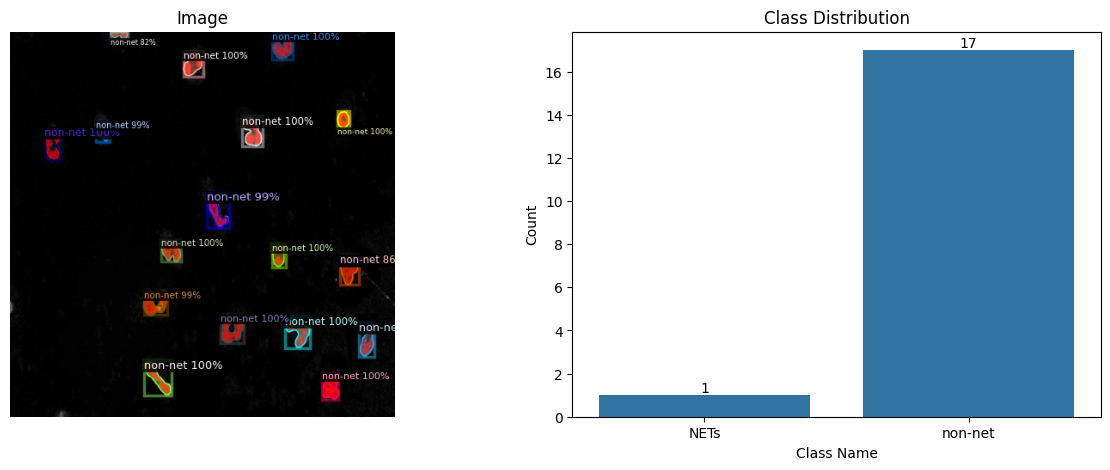

In [97]:
# Visualization of the validation result
plot_image_and_barchart(im_path, net_df)

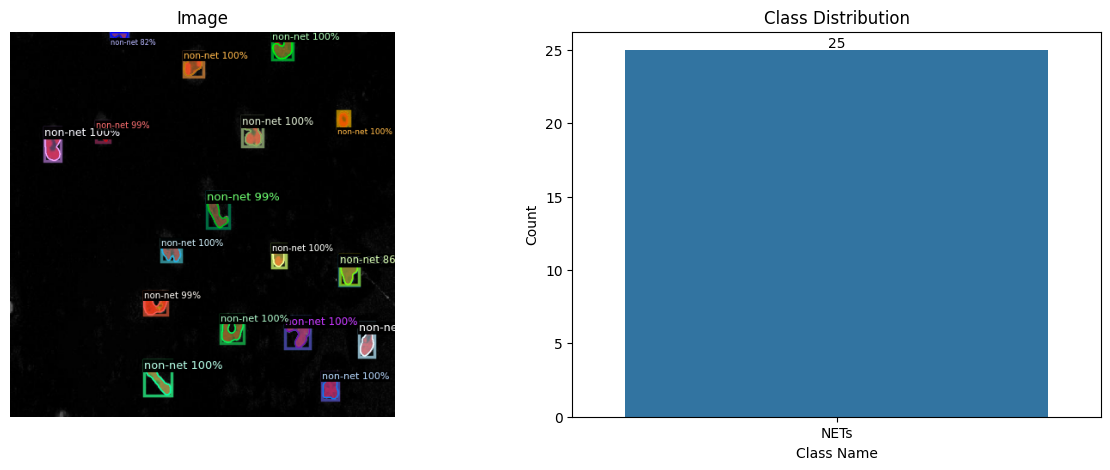

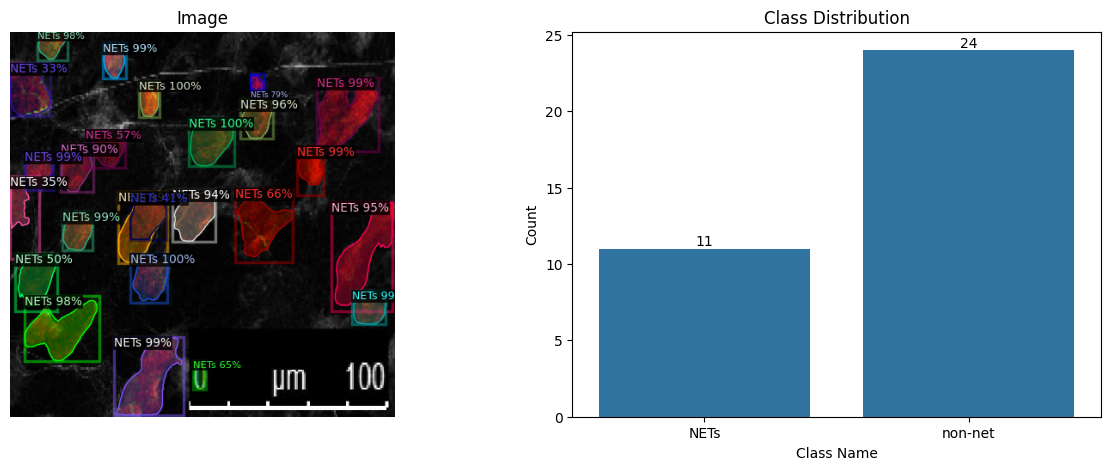

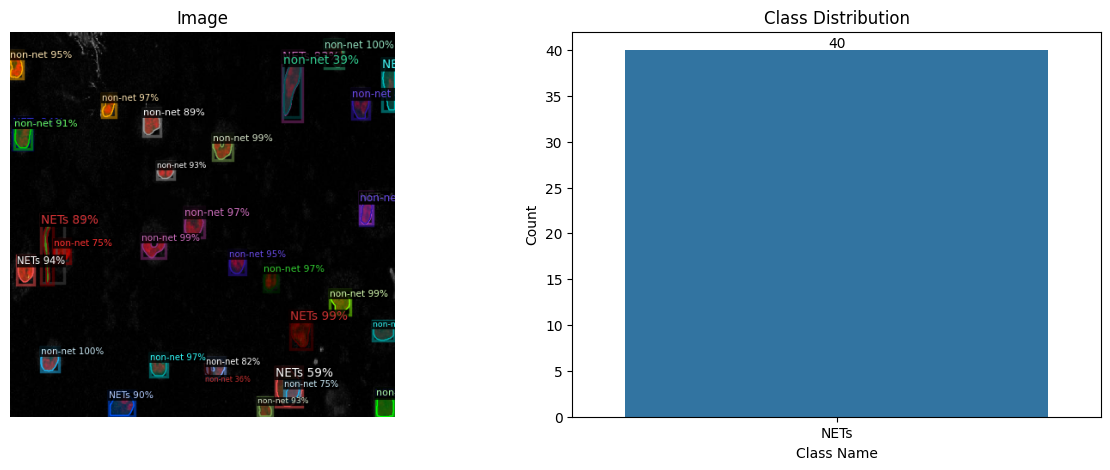

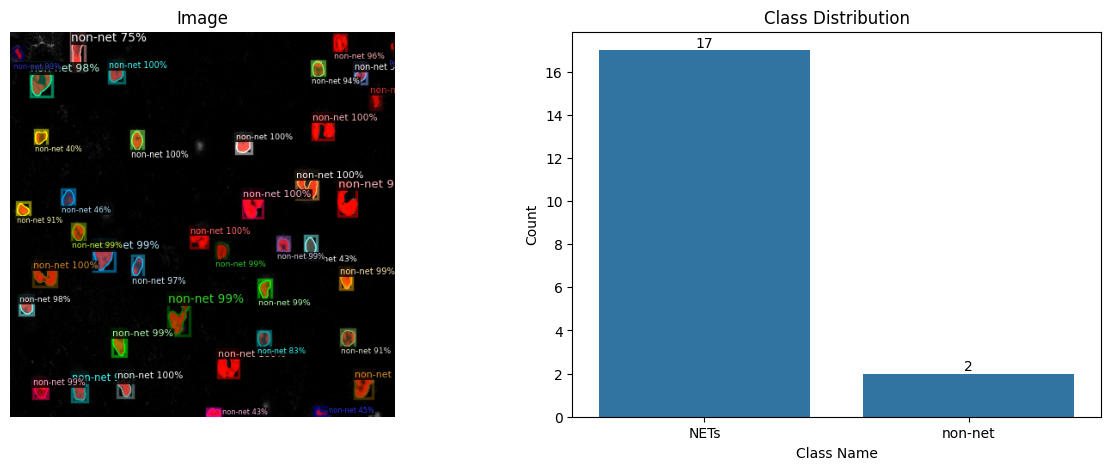

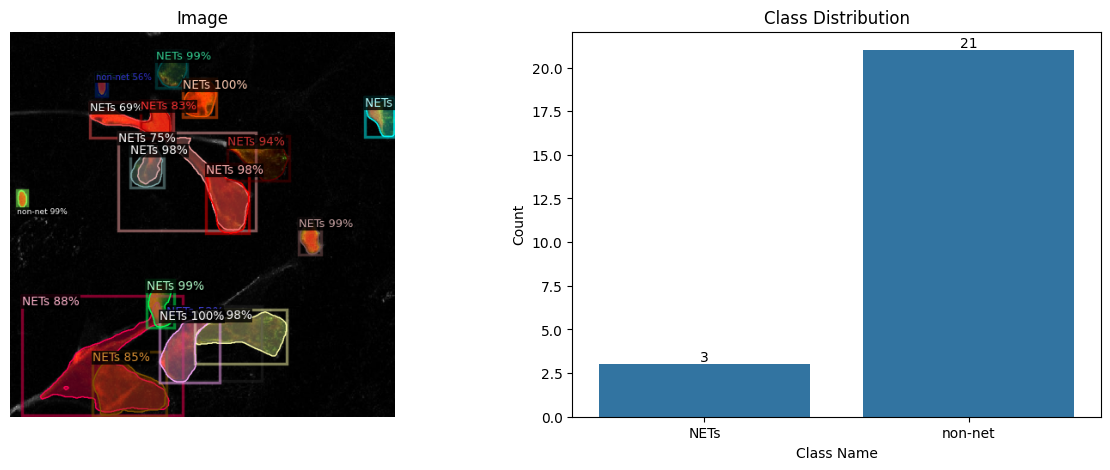

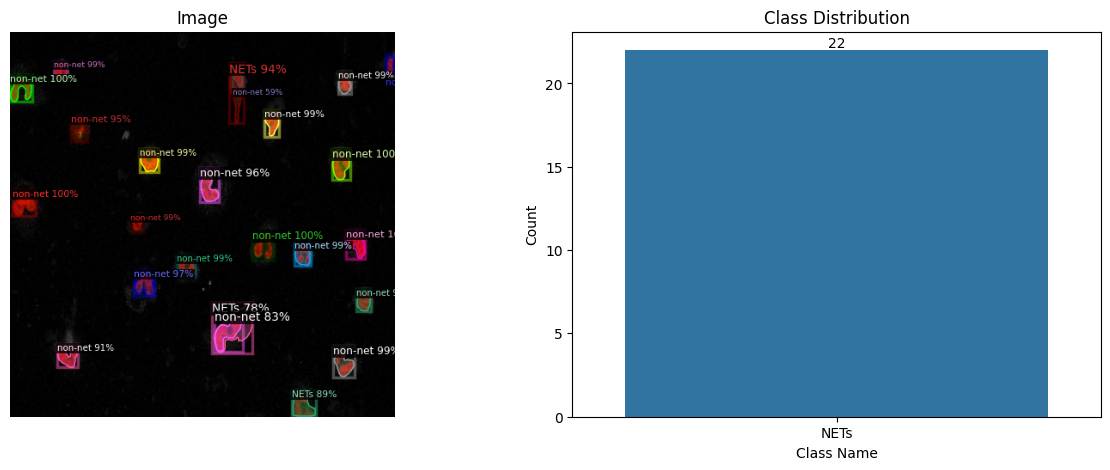

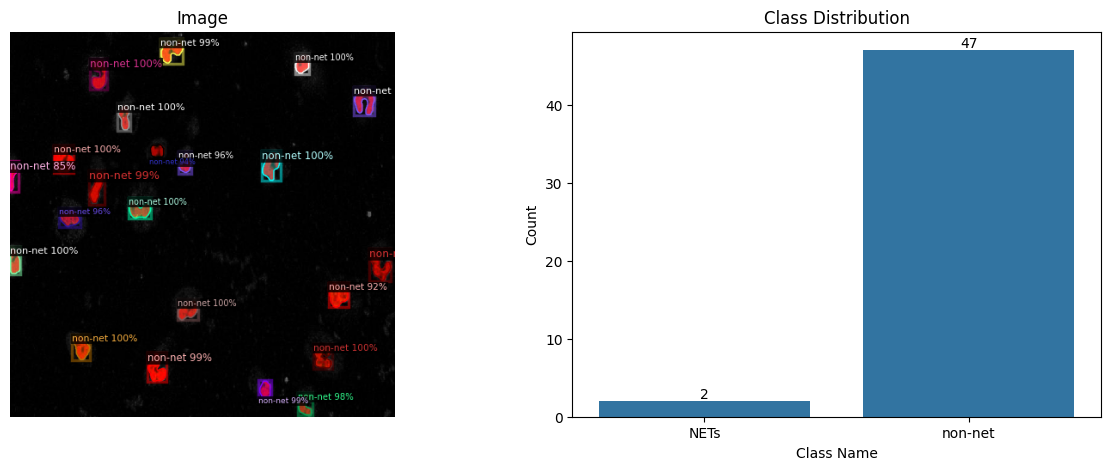

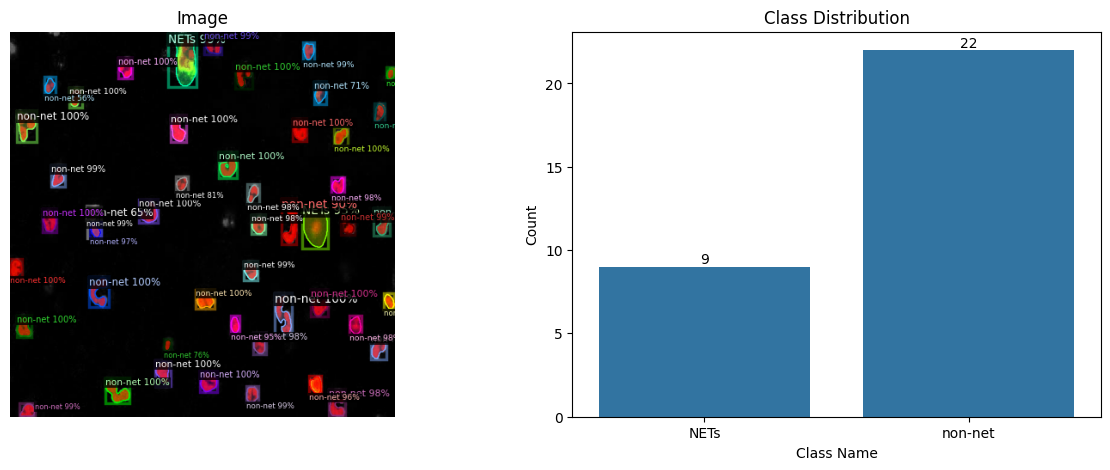

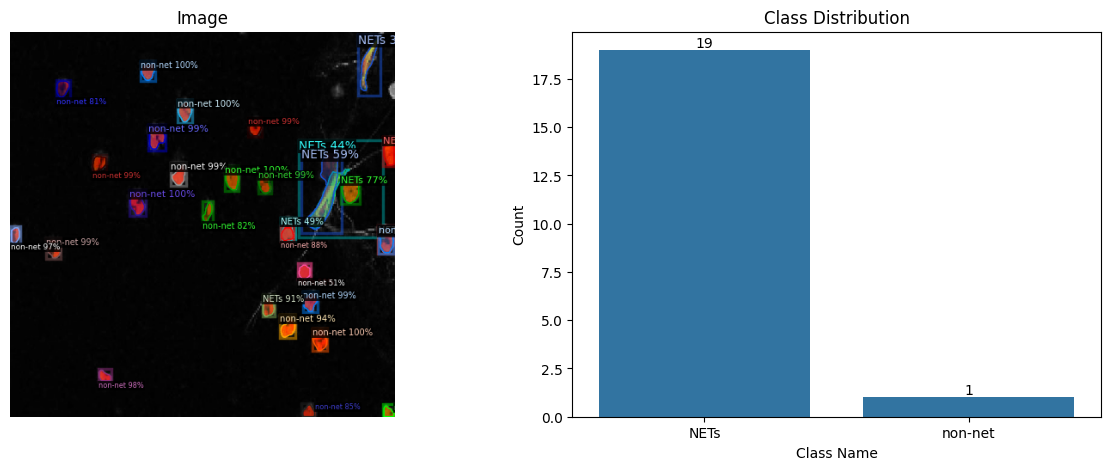

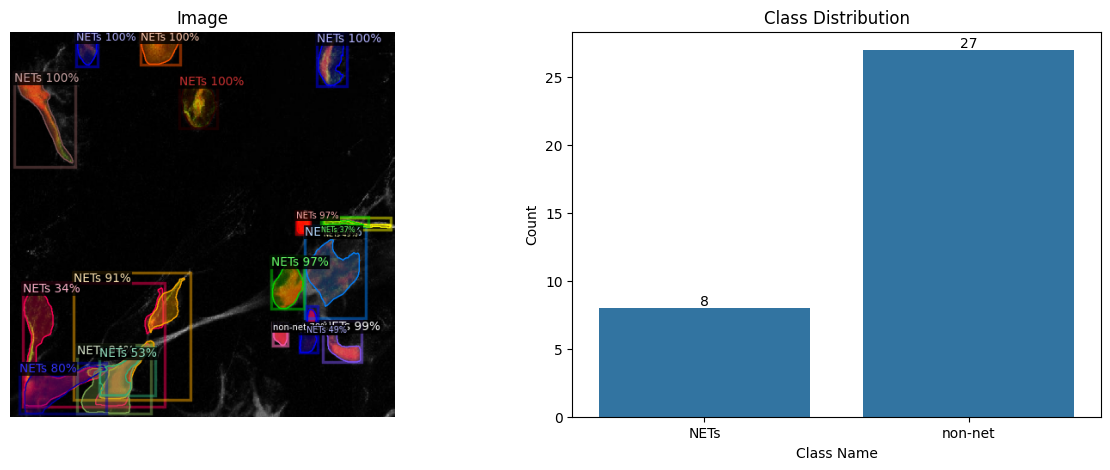

In [98]:
#Count predictions by class over the validation set
TEST_dir = Proj_dir + "/test_data"
pred_counter = Counter()
Net_predict = {}

# Get a list of all image files in the test directory
image_files = [os.path.join(TEST_dir, f) for f in os.listdir(TEST_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

for image_path in image_files:
    im = cv2.imread(image_path)
    # Check if the image was successfully loaded
    if im is None:
        print(f"Warning: Could not read image at {image_path}. Skipping.")
        continue

    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    outputs = predictor(im)
    v = Visualizer(
    im[:, :, ::-1],
    metadata=val_meta,
    scale=0.7,
    instance_mode=ColorMode.IMAGE_BW,
)
    classes = outputs["instances"].pred_classes.to("cpu").numpy().tolist()
    #pred_counter.update(classes)
    Net_predict = {x: classes.count(x) for x in set(classes)}
    nets_df = pd.DataFrame(list(Net_predict.items()), columns=['Class ID', 'Count'])
    nets_df['name'] = net_df['Class ID'].apply(lambda x: val_meta.thing_classes[x])
    path = out.get_image()[:, :, ::-1]

    #Plot for all the images
    plot_image_and_barchart(path, nets_df)



# Evaluation:


In [109]:
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0

In [100]:
def evaluate_model(dataset_dicts, predictor, metadata, iou_thresh=0.5):
    y_true = []
    y_pred = []

    for d in dataset_dicts:
        image = cv2.imread(d["file_name"])
        outputs = predictor(image)

        pred_instances = outputs["instances"].to("cpu")
        pred_masks = pred_instances.pred_masks.numpy()
        pred_classes = pred_instances.pred_classes.numpy()

        gt_masks = []
        gt_classes = []

        for ann in d["annotations"]:
            gt_classes.append(ann["category_id"])
            gt_masks.append(ann["segmentation"])

        # Convert GT polygons → masks
        from detectron2.structures import polygons_to_bitmask

        height, width = image.shape[:2]
        gt_masks = [
            polygons_to_bitmask(seg, height, width)
            for seg in gt_masks
        ]

        matched_gt = set()

        for i, pred_mask in enumerate(pred_masks):
            best_iou = 0
            best_gt_idx = -1

            for j, gt_mask in enumerate(gt_masks):
                if j in matched_gt:
                    continue

                iou = compute_iou(pred_mask, gt_mask)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_thresh:
                y_true.append(gt_classes[best_gt_idx])
                y_pred.append(pred_classes[i])
                matched_gt.add(best_gt_idx)
            else:
                # False positive
                y_true.append(-1)
                y_pred.append(pred_classes[i])

        # False negatives
        for j, gt_class in enumerate(gt_classes):
            if j not in matched_gt:
                y_true.append(gt_class)
                y_pred.append(-1)

    return y_true, y_pred

In [101]:
y_true, y_pred = evaluate_model(val_dicts, predictor, val_meta)
valid = [i for i in range(len(y_true)) if y_true[i] != -1 and y_pred[i] != -1]

y_true_clean = [y_true[i] for i in valid]
y_pred_clean = [y_pred[i] for i in valid]

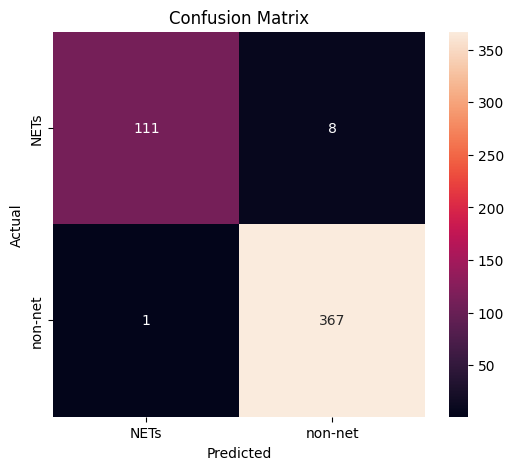

In [102]:
cm = confusion_matrix(y_true_clean, y_pred_clean)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=val_meta.thing_classes,
            yticklabels=val_meta.thing_classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [103]:
print(classification_report(
    y_true_clean,
    y_pred_clean,
    target_names=val_meta.thing_classes
))

              precision    recall  f1-score   support

        NETs       0.99      0.93      0.96       119
     non-net       0.98      1.00      0.99       368

    accuracy                           0.98       487
   macro avg       0.98      0.97      0.97       487
weighted avg       0.98      0.98      0.98       487



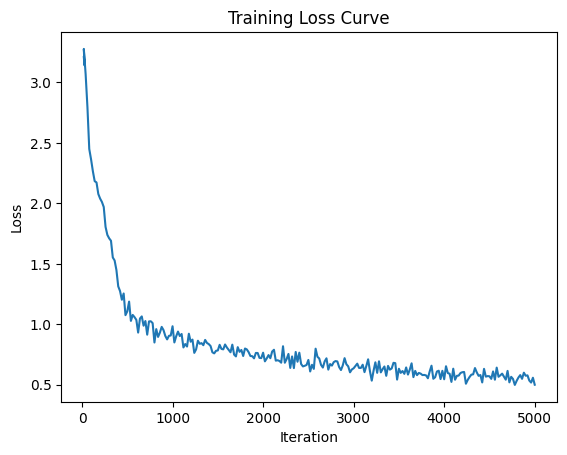

In [104]:
# Cost function plot
metrics_path = os.path.join(cfg.OUTPUT_DIR, "metrics.json")

iterations = []
losses = []

with open(metrics_path) as f:
    for line in f:
        data = json.loads(line)
        if "total_loss" in data:
            iterations.append(data["iteration"])
            losses.append(data["total_loss"])

plt.plot(iterations, losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# Coco evaluator
